**Task 2-Variance & Standard Deviation**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded=files.upload()

Saving supermarket_Sales.csv to supermarket_Sales.csv


In [3]:
df=pd.read_csv('supermarket_Sales.csv')
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,Cost of goods sold,Gross margin percentage,Gross income,Customer stratification rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Invoice ID                      1000 non-null   object 
 1   Branch                          1000 non-null   object 
 2   City                            1000 non-null   object 
 3   Customer type                   1000 non-null   object 
 4   Gender                          1000 non-null   object 
 5   Product line                    1000 non-null   object 
 6   Unit price                      1000 non-null   float64
 7   Quantity                        1000 non-null   int64  
 8   Tax 5%                          1000 non-null   float64
 9   Total                           1000 non-null   float64
 10  Date                            1000 non-null   object 
 11  Time                            1000 non-null   object 
 12  Payment                         100

In [9]:
df.isnull().sum()

,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Total,0


In [4]:
df['Gross income'].var()

137.09659414448348

In [5]:
df['Gross income'].std()

11.708825480998659

**Explanation:**

The variance shows how much the data varies from its average value. The standard deviation of 2.92 indicates that the quantity purchased typically varies by about 2.92 units from the average quantity.

**Task 3-Correlation & Probability**

In [6]:
#Correlation

correlation = df['Quantity'].corr(df['Total'])

print("Correlation:", round(correlation, 2))

Correlation: 0.71


There is a positive relationship between Quantity and Total. This means that as the quantity purchased increases, the total sales amount generally increases.

In [7]:
# Probability

ewallet_count = (df['Payment'] == 'Ewallet').sum()
total_transactions = len(df)

probability = ewallet_count / total_transactions

print("E-wallet transactions:", ewallet_count)
print("Total transactions:", total_transactions)
print("Probability:", round(probability, 2))
print("Percentage:", round(probability * 100, 2), "%")

E-wallet transactions: 345
Total transactions: 1000
Probability: 0.34
Percentage: 34.5 %


**Task 4- Handling Outliers**

In [16]:
for col in df.columns:
    num_col=[col for col in df.columns if df[col].dtype!='object']
    cat_col=[col for col in df.columns if df[col].dtypes=='object']
print(num_col)
print(cat_col)

['Unit price', 'Quantity', 'Tax 5%', 'Total', 'Cost of goods sold', 'Gross margin percentage', 'Gross income', 'Customer stratification rating']
['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Date', 'Time', 'Payment']


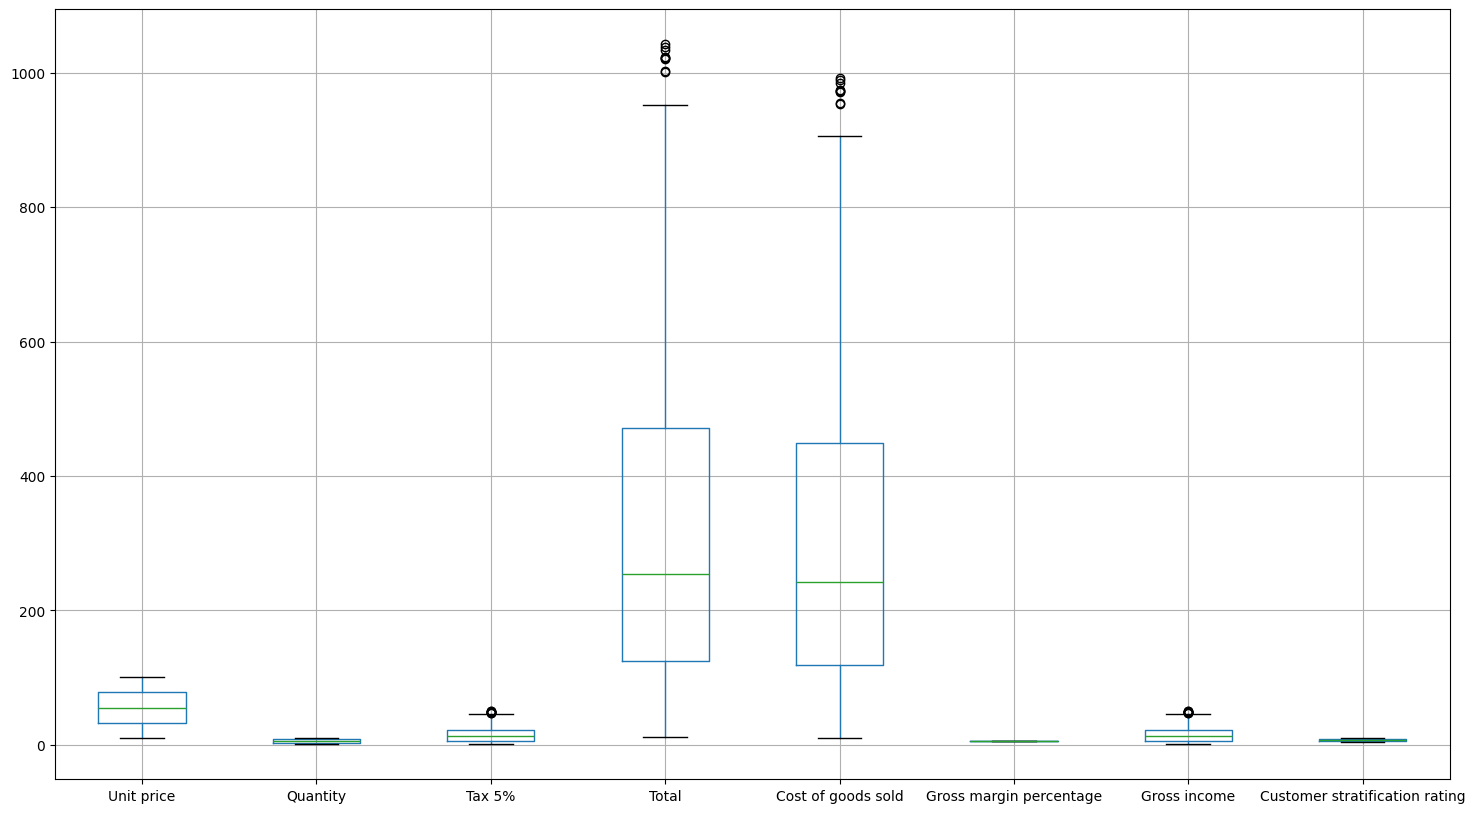

In [23]:
#outliers
df[num_col].boxplot(figsize=(18,10))
plt.show()

In [24]:
#Removal of outliers
def outliers(df,col):
  q1=df[col].quantile(0.25)
  q3=df[col].quantile(0.75)
  IQR=q3-q1
  lower=q1-1.5*IQR
  upper=q3+1.5*IQR
  df[col]=df[col].clip(lower,upper)


In [25]:

outliers(df,'Tax 5%')
outliers(df,'Total')
outliers(df,'Cost of goods sold')
outliers(df,'Gross income')

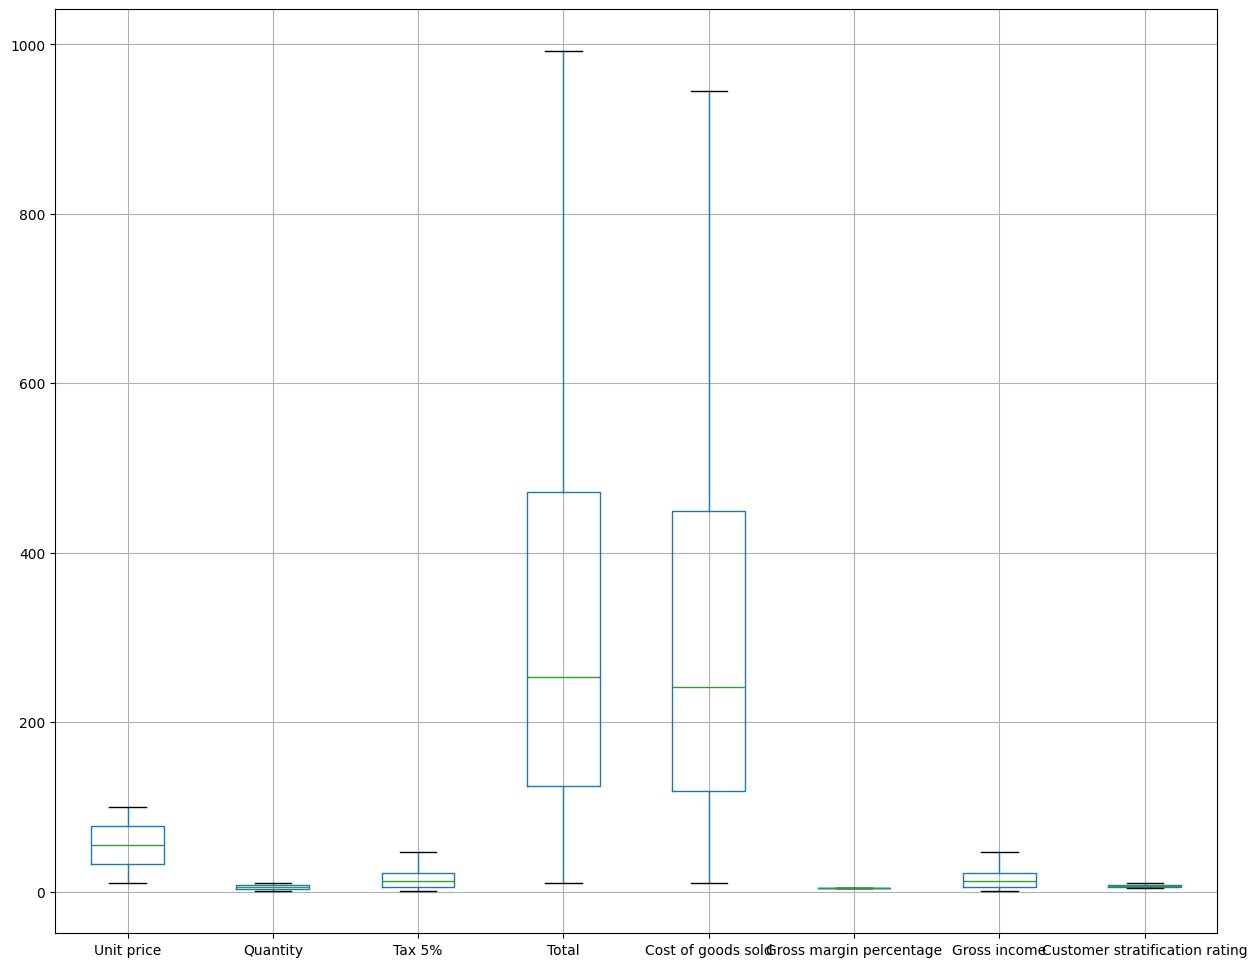

In [26]:
df[num_col].boxplot(figsize=(15,12))
plt.show()

**Outliers can affect data analysis in several ways**

Outliers can significantly influence statistical results and may lead to inaccurate conclusions, so they should be identified and examined carefully.

**Task 5: Matplotlib Visualization**

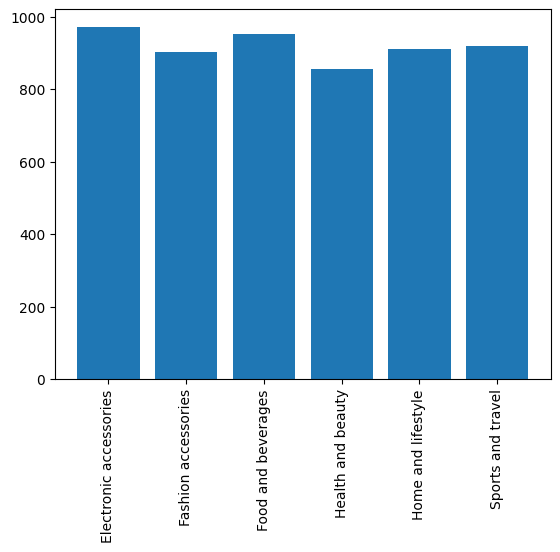

In [38]:
product_quantity = df.groupby('Product line')['Quantity'].sum()

plt.bar(product_quantity.index, product_quantity.values)
plt.xticks(rotation=90)
plt.show()

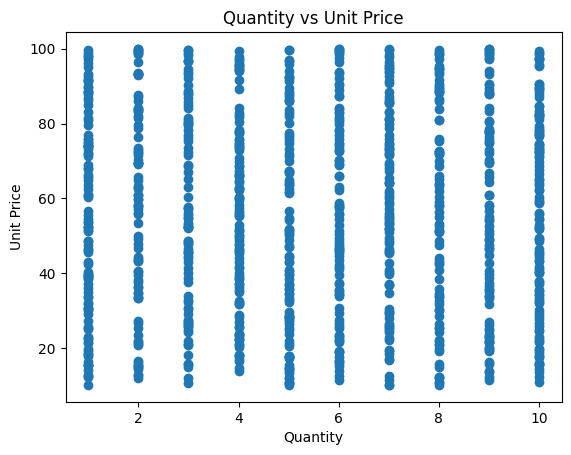

In [39]:
plt.scatter(df['Quantity'], df['Unit price'])
plt.xlabel('Quantity')
plt.ylabel('Unit Price')
plt.title('Quantity vs Unit Price')
plt.show()

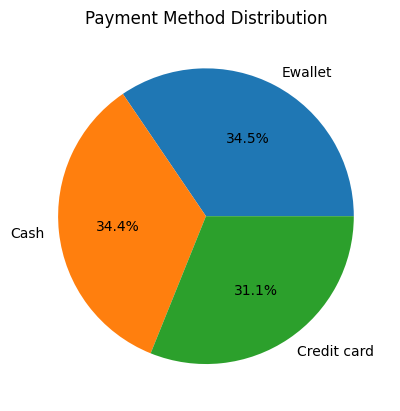

In [40]:
payment = df['Payment'].value_counts()

plt.pie(payment, labels=payment.index, autopct='%1.1f%%')
plt.title('Payment Method Distribution')
plt.show()

**Task 6- Seaborn Visualization**

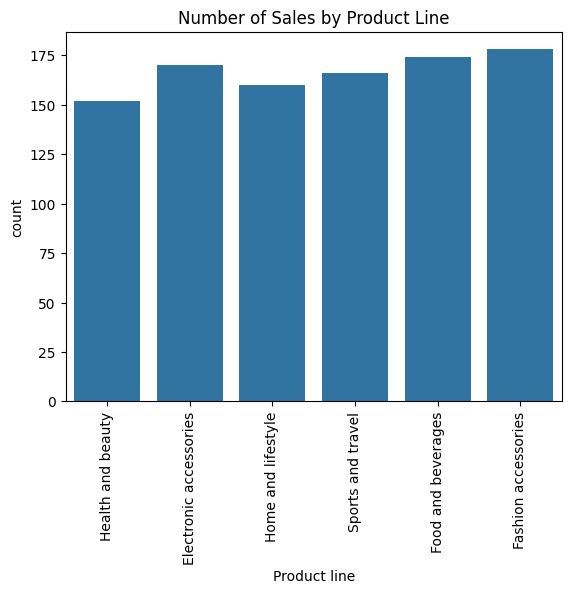

In [41]:
sns.countplot(x='Product line', data=df)

plt.title('Number of Sales by Product Line')
plt.xticks(rotation=90)
plt.show()

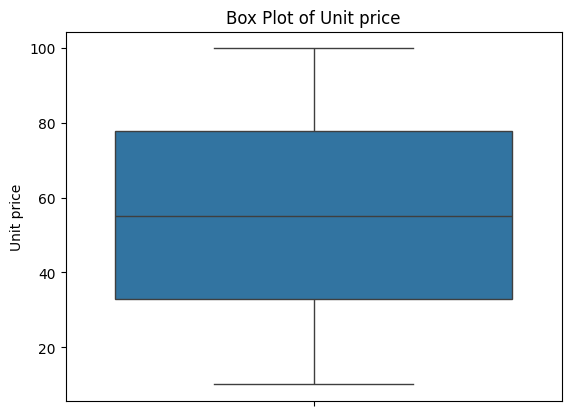

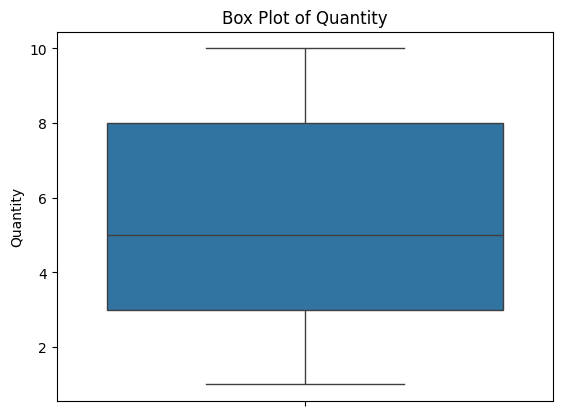

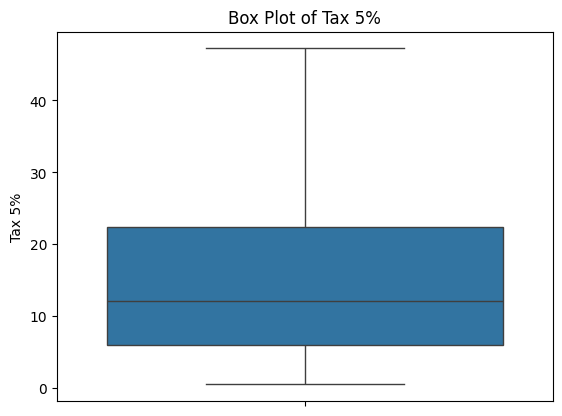

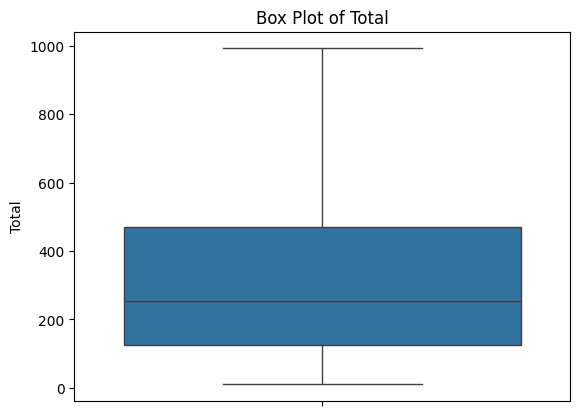

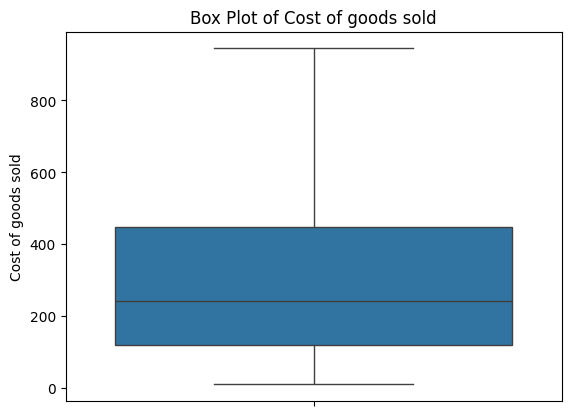

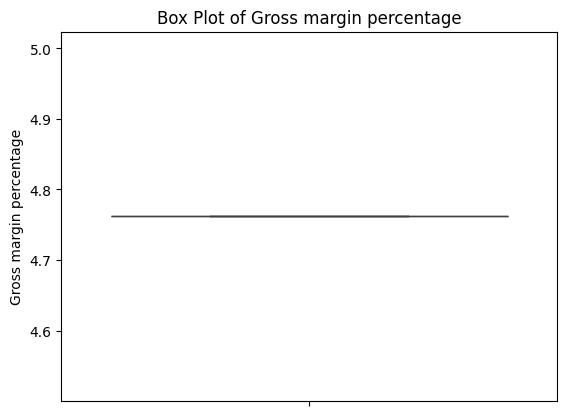

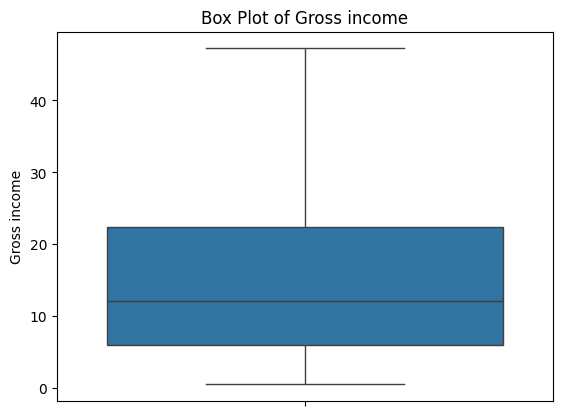

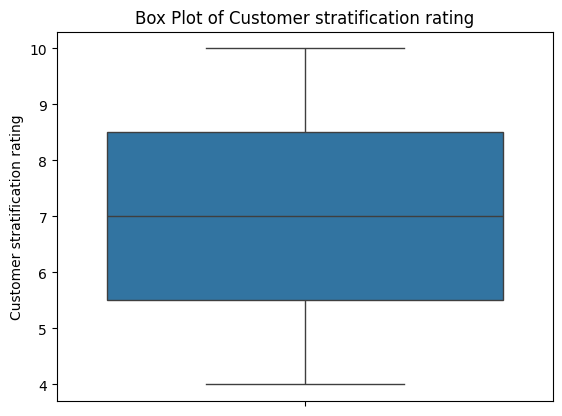

In [43]:
for col in num_col:
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.show()

<Axes: >

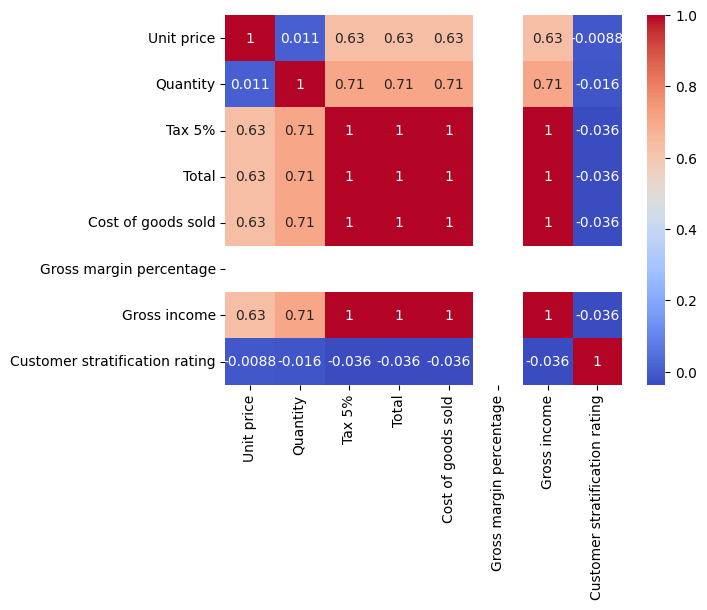

In [45]:
sns.heatmap(df[num_col].corr(),annot=True,cmap='coolwarm')

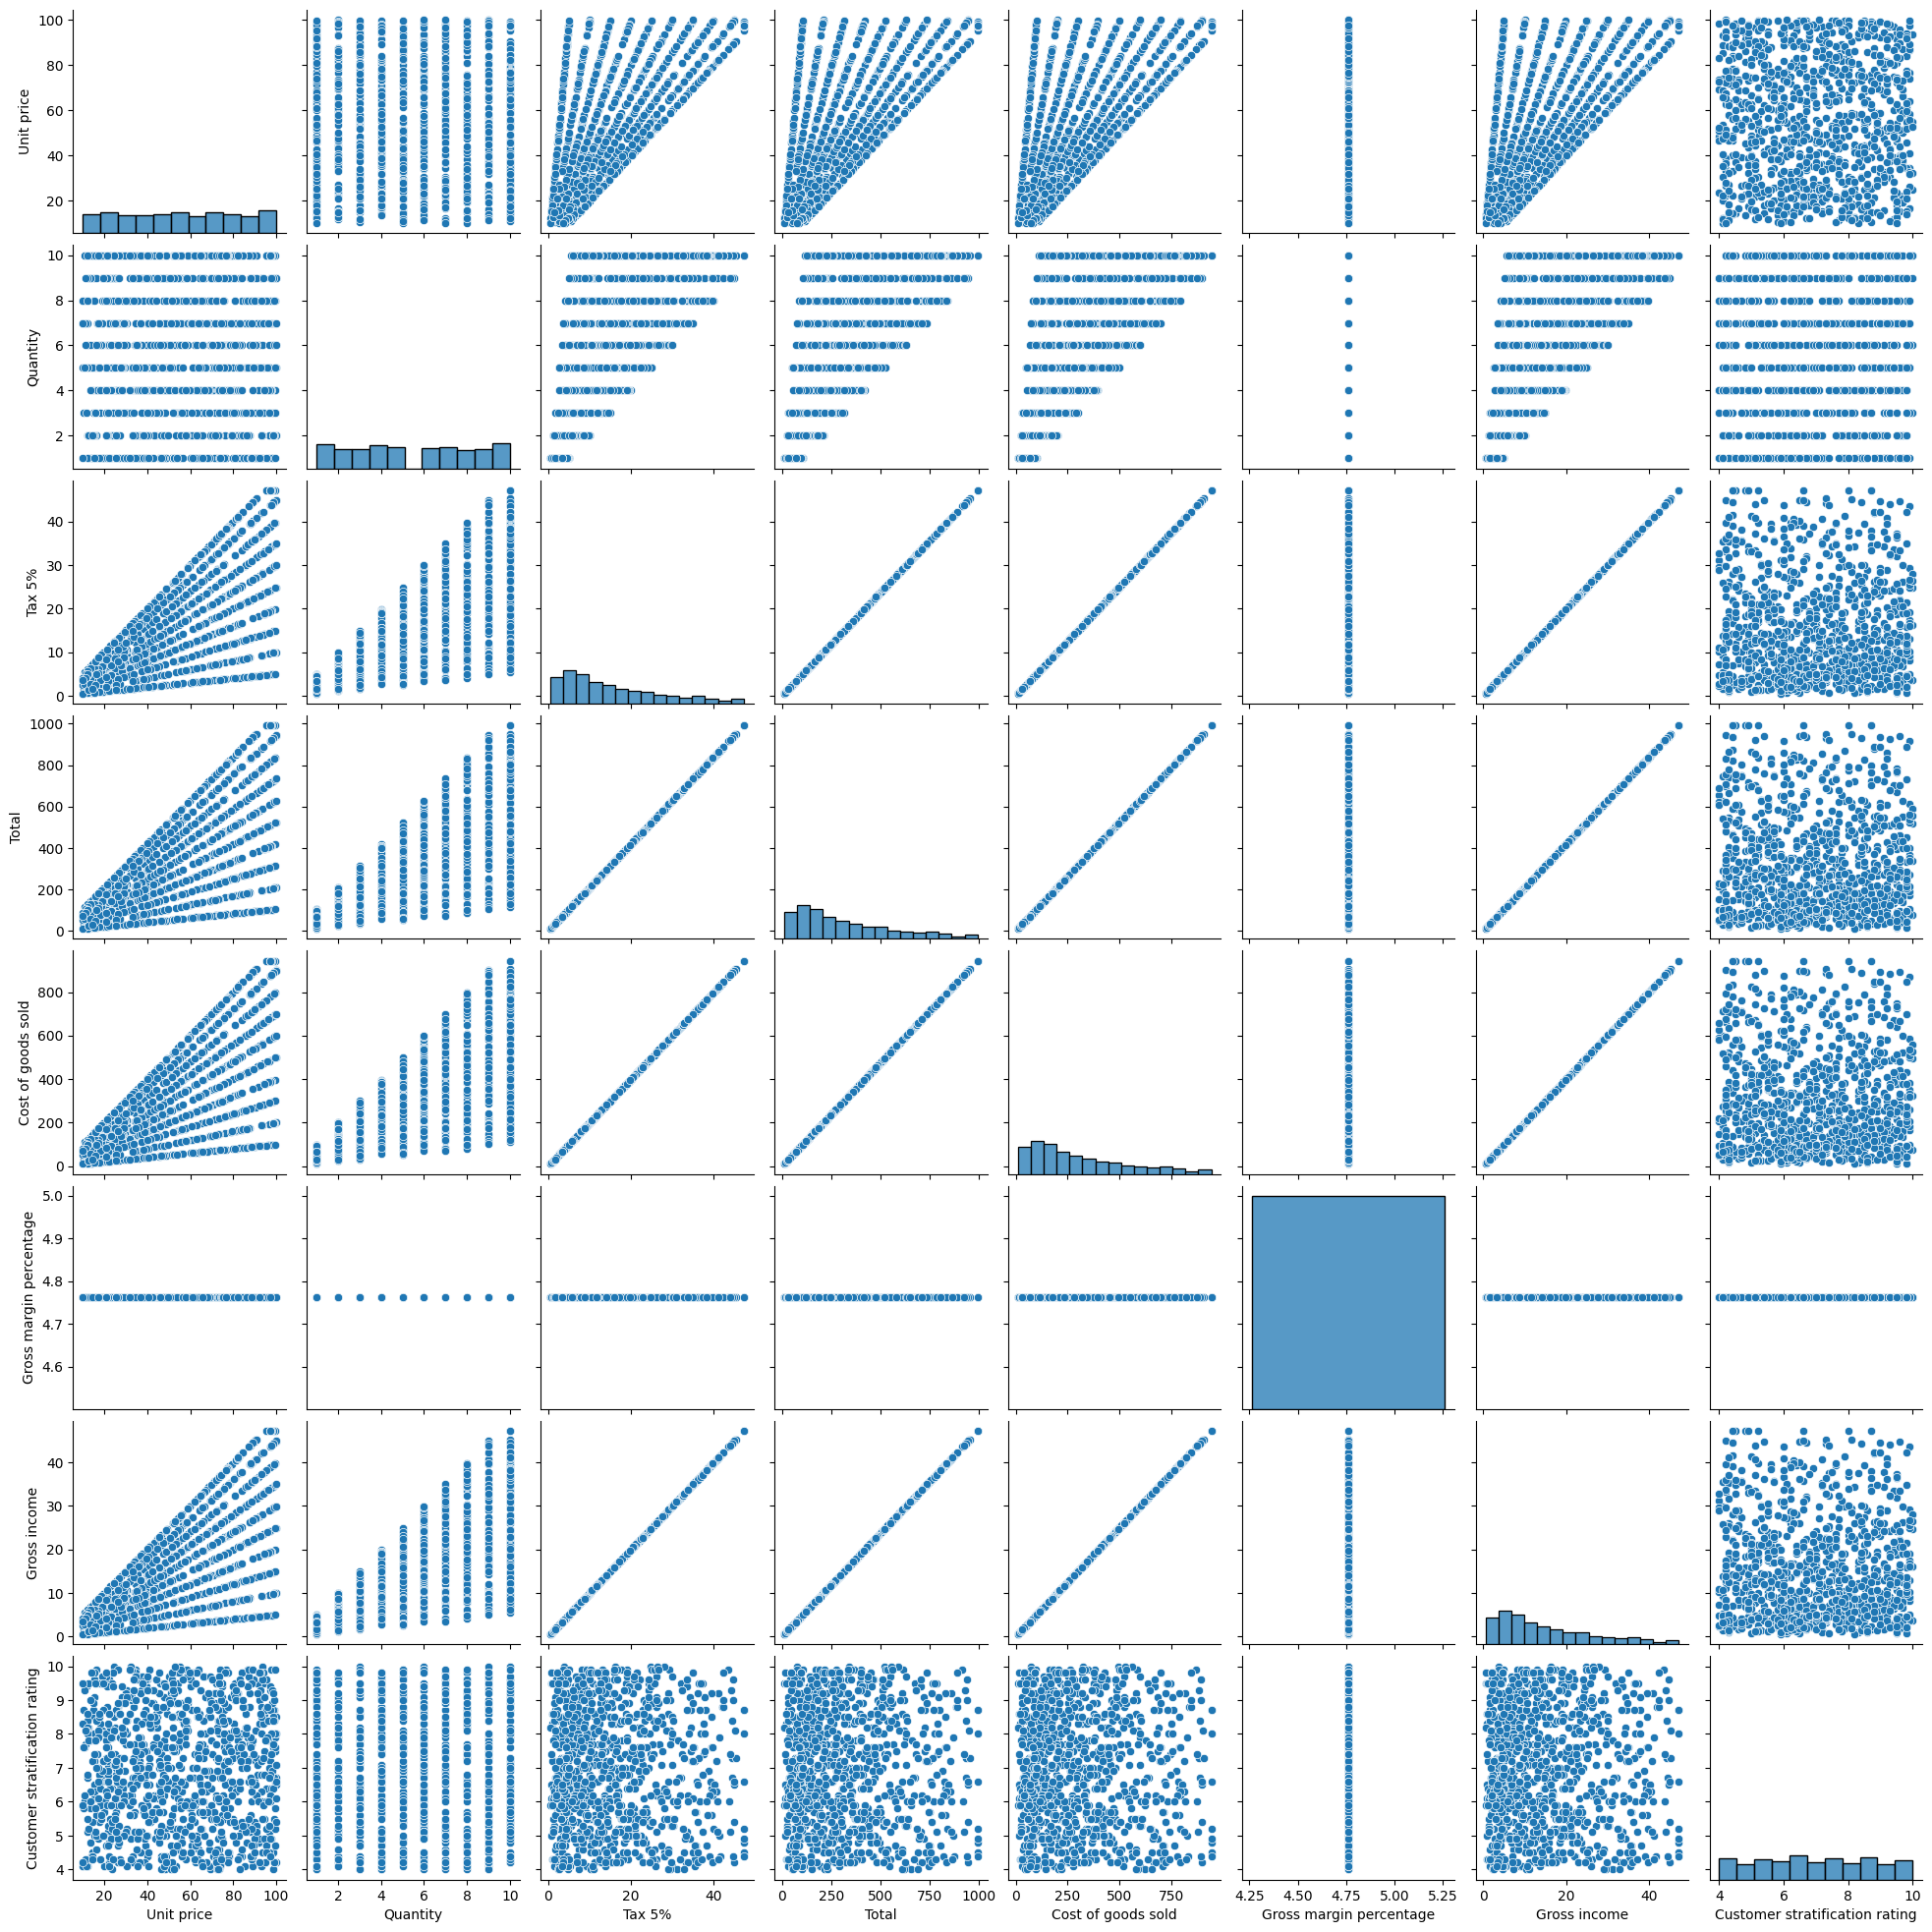

In [46]:
sns.pairplot(df[num_col])